## Inledning: 
det här datasetet är fokus på serier och netflix. Det innehåller både titel, år, rating utav målgrupp, regissörer, beskrivning och skådespelare.  
Notebooken undersöker hur innehållet ser ut genom olika analys/grafer.

In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [157]:
df = pd.read_csv("data/netflix_titles.csv")

In [158]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## fråga varför visas Nan (not a number) för? 
det är för att dataset som jag undersökte,hade saknat flera värden i kolumner på regissör, skådespelare och land. Orsaken är nog för att dataset som är från keggle, registerades inte korrekt när det skapades. Men valde att satsa på det ändå, eftersom jag kände att det hade mycket data som jag kände var användbar för analysen.

In [159]:
df.shape

(8807, 12)

In [160]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [ ]:
df["date_added"] = pd.to_datetime(df["date_added"].str.strip())
df["type"] = df["type"].astype("category")
df["rating"] = df["rating"].astype("category")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   str           
 1   type          8807 non-null   category      
 2   title         8807 non-null   str           
 3   director      6173 non-null   str           
 4   cast          7982 non-null   str           
 5   country       7976 non-null   str           
 6   date_added    8797 non-null   datetime64[us]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   category      
 9   duration      8804 non-null   str           
 10  listed_in     8807 non-null   str           
 11  description   8807 non-null   str           
dtypes: category(2), datetime64[us](1), int64(1), str(8)
memory usage: 705.5 KB


## Förbättring av datatyper
datatvätt genomfördes med att ta bort onödiga mellanslag och konvertera till datum-format.

Det resulterar i att datan blir enklare att genomföra och ger en underlättande känsla på analyser baserad på datum och tid.

Efter att jag hade byggt vidare på datatvätten, så lyckades jag ändra ett par kolumner från str, till category och datetime-format. Den hade även förminskat användandet av minnet i datasetet också. Samt att det blev lite mer tydligt.

In [162]:
df.describe()

,date_added,release_year
count,8797,8807.000000
mean,2019-05-17 05:59:08.436967,2014.180198
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-06 00:00:00,2013.000000
50%,2019-07-02 00:00:00,2017.000000
75%,2020-08-19 00:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.819312


In [163]:
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [164]:
df.duplicated().sum()

np.int64(0)

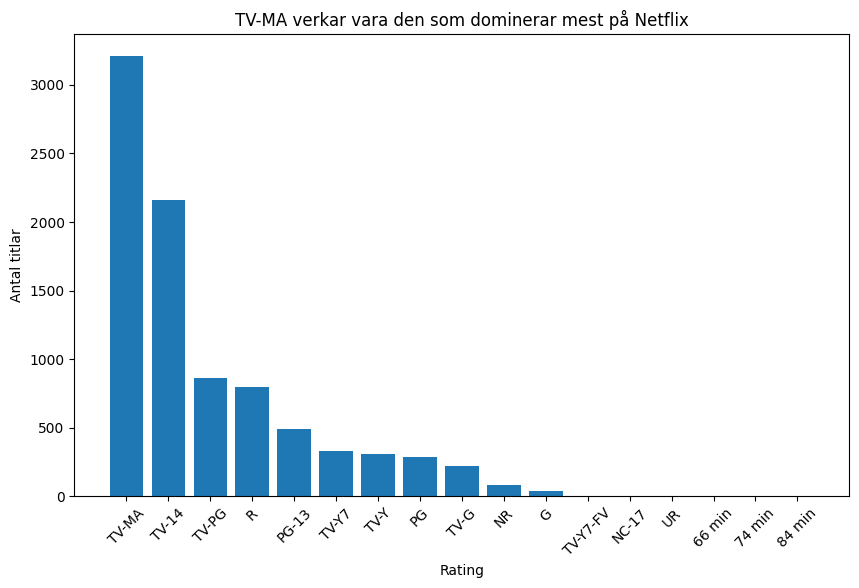

In [165]:
clean_df = df[df["rating"].str.contains("min", na=False) == False]
ratings = clean_df["rating"].value_counts()
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(ratings.index.astype(str), ratings.to_numpy())
ax.set_title("TV-MA verkar vara den som dominerar mest på Netflix")
ax.set_xlabel("Rating")
ax.set_ylabel("Antal titlar")

plt.xticks(rotation=45)

plt.show()

## fråga?: Vilka ratings brukar förekomma oftast på Netflix?
svar: med hjälp utav stapeldiagramet som jag valde, så fick jag en visning på alla ratings och olika typer av värde baserad på kategori, vare sig det gäller skräck, action eller komedi.

baserad på grafen så är TV-Ma den största gällande rating grafen på netflix.
-anledningen är att de flesta filmer är riktad till ungdomar och vuxna.

<BarContainer object of 10 artists>

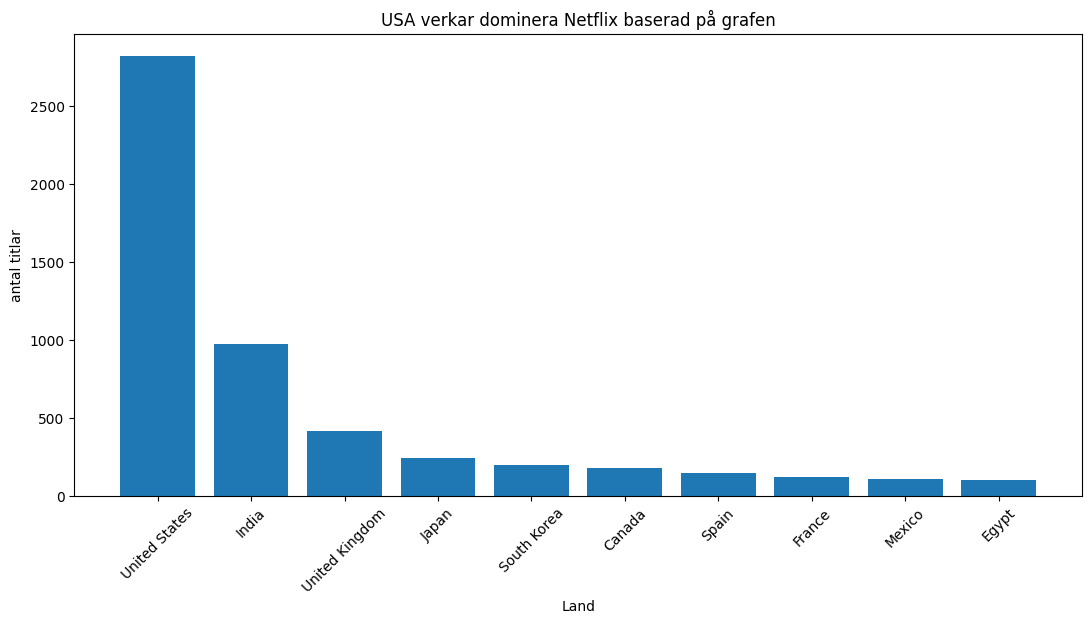

In [166]:
countries = df["country"].value_counts().head(10)
fig, ax = plt.subplots(figsize=(13,6))
ax.set_title("USA verkar dominera Netflix baserad på grafen")
ax.set_xlabel("Land")
ax.set_ylabel("antal titlar")
plt.xticks(rotation=45)
ax.bar(countries.index, countries.values)

## fråga? vilka länder dominerar Netflix baserad på grafen?

Med tanke på att Neflix har blivit världkänd i de flesta länderna, så valde jag ett stapeldiagram, som ger en jämförelse mellan de olika länder som använder netflix mestadels. Man kan även se baserad på antalet titlar som är tillgängliga dessutom.

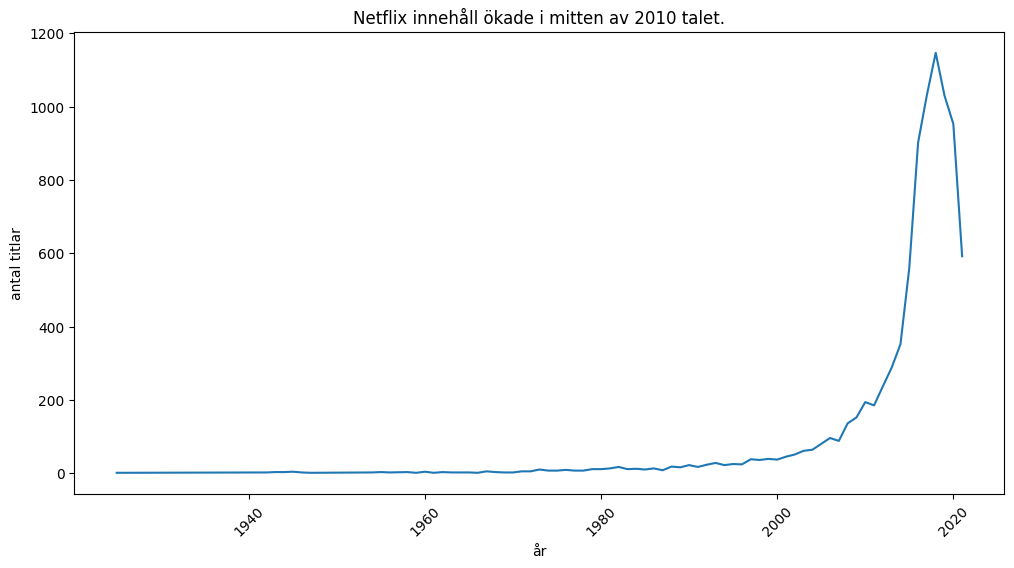

In [167]:
per_year = df["release_year"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(12,6))
ax.set_title("Netflix innehåll ökade i mitten av 2010 talet.")
ax.set_xlabel("år")
ax.set_ylabel("antal titlar")
plt.xticks(rotation=45)
ax.plot(per_year.index, per_year.values)
plt.show()

## Fråga: hur mycket har innehållet i Netflix förändrats över tid?

svar: jag valde ett linjediagram för grafens innehåll och höjd.
enligt grafen så hade utvecklingen sakta gått upp och blivit alltmer populärt/trendigt i mitten av 2010 talet, vilket gjorde att netflix blev mer vanligare i alla hushåll.

## Avslutning

Analysen som jag valde, så visar datasetet hur Netflix är dominerad av innehåll i olika länder, att rating system visas. Men att det finns begränsningar, då vissa kolumen hade saknade värden baserad regissör,skådespelare och land. Vilket blir svårt att dra en hel slutsats om alla länder och alla personer bakom innehållet.